In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=GROQ_API_KEY)

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [3]:
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [4]:
def characters(state: State):
    """Generates characters"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

In [5]:
def settings(state: State):
    """Generate Story Settings"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

In [6]:
def premises(state: State):
    """Generate premises"""
    msg = llm.invoke(f"Write a one sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

In [7]:
def combine_elements(state: State):
    msg = llm.invoke(
        "Write a short story introduction using these elements: \n"
        f"Characters : {state['characters']} \n"
        f"Setting : {state['settings']} \n"
        f"Premise : {state['premises']}"
    )
    return {"story_intro": msg.content}

In [8]:
builder = StateGraph(State)

builder.add_node("character", characters)
builder.add_node("setting", settings)
builder.add_node("premise", premises)
builder.add_node("combine", combine_elements)

builder.add_edge(START, "character")
builder.add_edge(START, "setting")
builder.add_edge(START, "premise")

builder.add_edge("character", "combine")
builder.add_edge("premise", "combine")
builder.add_edge("setting", "combine")

builder.add_edge("combine", END)

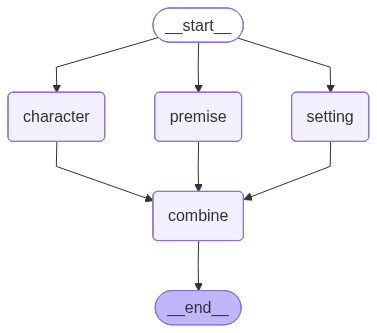

In [9]:
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
state = {"topic": "Time Travel"}
result = graph.invoke(state)
print(result['story_intro'])

The black marble archway of the Vault of Moments loomed before her, a narrow, gnarled throat of stone etched with runes that pulsed faintly in a phosphorescent blue. Elara Kestrel stepped through, humming the lullaby her mother had sung on her last breath—an old tune that had slipped from her mind since the day the world had stopped being linear. She had spent a decade cataloguing paradoxes, each entry a fragile thread in a tapestry that threatened to unravel if she let it. She was a weary archivist of time, and the Vault was the only place where the past and future slept in the same breath.

The air inside was cool, the scent of ozone mingling with the old paper of forgotten journals. The cavern opened into a vast chamber whose ceiling was a ribbed lattice of obsidian, pulsing with a slow, rhythmic thrum. Crystal prisms hung from the ceiling like a chandelier of light, scattering prismatic rain across a floor of interlocking silver tiles that reflected the room in a dizzying web of mi